In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

!unzip /content/drive/MyDrive/'Forest Fire Dataset.zip' -d /content

!ls /content/'Forest Fire Dataset'

 9144b612-7ca6-4cfa-aa5a-1f721e85710e.pdf
'ARYA KHOSRAVIRD.pdf'
'carta di identita.pdf'
'Colab Notebooks'
'Copy of تکلیف شماره یک آریا خسروی راد.gdoc'
'Forest Fire Dataset.zip'
'letter of recommendation.pdf'
'resilient main'
 Self_Declaration_English_Arya_Khosravirad.pdf
 TrustWalletBackup
 wellness.drawio
Archive:  /content/drive/MyDrive/Forest Fire Dataset.zip
   creating: /content/Forest Fire Dataset/
   creating: /content/Forest Fire Dataset/Forest Fire Dataset/
   creating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0002.jpg  
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0015.jpg  
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0027.jpg  
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0038.jpg  
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0040.jpg  
  inflating: /content/Fores

In [ ]:
import os, glob, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    adjusted_rand_score,
    v_measure_score,
    normalized_mutual_info_score,
)

import pandas as pd
from tqdm import tqdm
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_fire_path = '/content/Forest Fire Dataset/Training/fire'
train_nofire_path = '/content/Forest Fire Dataset/Training/nofire'
test_path = '/content/Forest Fire Dataset/Testing'

In [ ]:
def list_file_types_in_directory(directory):
    file_types = set([file.split('.')[-1] for file in os.listdir(directory)
                      if os.path.isfile(os.path.join(directory, file))])
    return file_types

train_fire_file_types = list_file_types_in_directory(train_fire_path)
train_nofire_file_types = list_file_types_in_directory(train_nofire_path)
test_file_types = list_file_types_in_directory(test_path)

print("File types in Train Fire:", train_fire_file_types)
print("File types in Train No Fire:", train_nofire_file_types)
print("File types in Test:", test_file_types)

File types in Train Fire: {'jpg'}
File types in Train No Fire: {'jpg'}
File types in Test: {'jpg'}


In [ ]:
def list_images(root, exts=(".jpg",)):
    return [p for p in glob.glob(os.path.join(root, "*"))
            if os.path.isfile(p) and p.endswith(exts)]

train_paths = list_images(train_fire_path) + list_images(train_nofire_path)
test_paths  = list_images(test_path)

print(f"Train: {len(train_paths)}  | Test: {len(test_paths)}")

Train: 1520  | Test: 380


In [ ]:
def is_bad_image(img_rgb, file=None, min_unique=50, mean_lo=5, mean_hi=250, blur_thr=20.0):

    if img_rgb is None:
        print(f"[Skipped unreadable] {file}" if file else "[Skipped unreadable]")
        return True

    # grayscale version
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) if img_rgb.ndim == 3 else img_rgb

    # 1) Near-blank check
    if np.unique(gray).size < min_unique:
        print(f"[Skipped near-blank] {file}" if file else "[Skipped near-blank]")
        return True

    m = float(gray.mean())
    if m < mean_lo or m > mean_hi:
        print(f"[Skipped extreme brightness] {file} (mean={m:.1f})" if file else f"[Skipped extreme brightness] (mean={m:.1f})")
        return True

    # 2) Blur check
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    if lap_var < blur_thr:
        print(f"[Skipped blurry] {file} (var={lap_var:.1f})" if file else f"[Skipped blurry] (var={lap_var:.1f})")
        return True

    return False

In [ ]:
def load_rgb_cv2(p, size):

    img = cv2.imread(p)
    if img is None:
        raise ValueError(f"Failed to read image: {p}")
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if is_bad_image(img, file=p):
        raise ValueError("bad_image")

    return img.astype(np.float32)

In [ ]:
backbone = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3), pooling="avg")
backbone.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.9, 1.1),
    fill_mode="nearest"
)

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
def extract_resnet_embeddings_mean_cv2(paths, n_aug=1, seed=None,
                                       aug_datagen=None, eval_datagen=None):

    rng = np.random.RandomState(seed) if seed is not None else None
    embs, kept_idx = [], []

    for i, p in enumerate(tqdm(paths, desc="Embeddings (TTA-mean)")):
        try:
            arr0 = load_rgb_cv2(p, (224, 224))

            views = []
            x0 = eval_datagen.standardize(arr0.copy())
            views.append(x0)

            for _ in range(int(n_aug)):
                s = None if rng is None else int(rng.randint(0, 2**31 - 1))
                aug = aug_datagen.random_transform(arr0.copy(), seed=s)
                aug = aug_datagen.standardize(aug)
                views.append(aug)

            batch = np.stack(views, axis=0).astype(np.float32)
            vecs  = backbone.predict(batch, verbose=0)
            embs.append(vecs.mean(axis=0))
            kept_idx.append(i)

        except Exception as e:
            tqdm.write(f"Skip {p}: {e}")

    if not embs:
        raise ValueError("No embeddings produced.")

    return np.vstack(embs), np.array(kept_idx, dtype=int)

In [ ]:
train_embeds, train_valid_idx = extract_resnet_embeddings_mean_cv2(
    train_paths, n_aug=1, seed=42, aug_datagen=train_datagen, eval_datagen=eval_datagen)

test_embeds, test_valid_idx = extract_resnet_embeddings_mean_cv2(
    test_paths, n_aug=0, seed=None, aug_datagen=None, eval_datagen=eval_datagen)

print("\nTrain embeds:", train_embeds.shape, "| Test embeds:", test_embeds.shape)

Embeddings (TTA-mean):  15%|█▍        | 223/1520 [00:29<01:48, 11.93it/s]

[Skipped blurry] /content/Forest Fire Dataset/Training/fire/fire_0168.jpg (var=11.2)
Skip /content/Forest Fire Dataset/Training/fire/fire_0168.jpg: bad_image


Embeddings (TTA-mean):  27%|██▋       | 412/1520 [00:48<01:34, 11.73it/s]

[Skipped blurry] /content/Forest Fire Dataset/Training/fire/fire_0934.jpg (var=10.8)
Skip /content/Forest Fire Dataset/Training/fire/fire_0934.jpg: bad_image


Embeddings (TTA-mean):  35%|███▍      | 529/1520 [01:00<01:31, 10.88it/s]

...

[Skipped blurry] /content/Forest Fire Dataset/Training/nofire/nofire_0419.jpg (var=7.8)
Skip /content/Forest Fire Dataset/Training/nofire/nofire_0419.jpg: bad_image


Embeddings (TTA-mean):  98%|█████████▊| 371/380 [00:36<00:00, 14.62it/s]

[Skipped blurry] /content/Forest Fire Dataset/Testing/nofire_0574.jpg (var=18.3)
Skip /content/Forest Fire Dataset/Testing/nofire_0574.jpg: bad_image


Embeddings (TTA-mean): 100%|██████████| 380/380 [00:37<00:00, 10.11it/s]


Train embeds: (1515, 2048) | Test embeds: (379, 2048)


In [ ]:
scaler = StandardScaler().fit(train_embeds)
train_z = scaler.transform(train_embeds)
test_z  = scaler.transform(test_embeds)

In [ ]:
pca_full = PCA(svd_solver="full", random_state=42).fit(train_z)

/tmp/ipython-input-3206699502.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].grid(True); ax[0].legend()


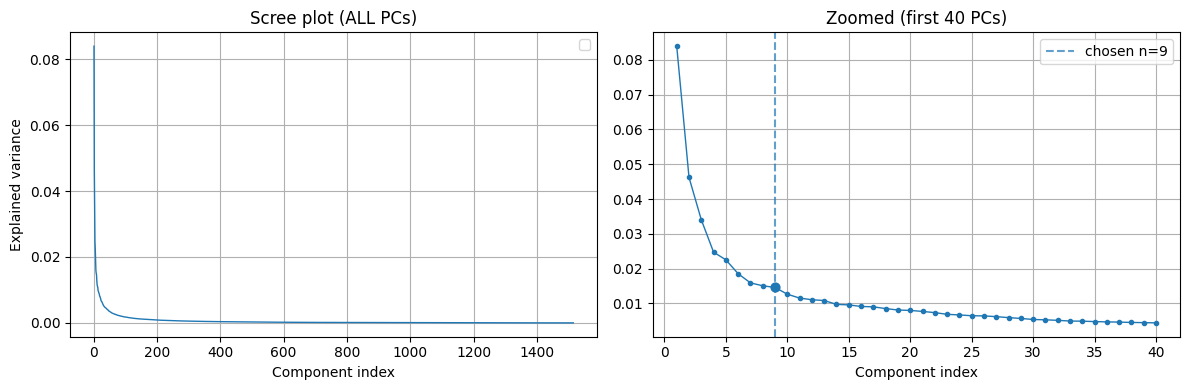

In [ ]:
choice = 9
Nzoom = 40

fig, ax = plt.subplots(1, 2, figsize=(12,4))
eig = pca_full.explained_variance_ratio_

xs_full = range(1, len(eig)+1)
ax[0].plot(xs_full, eig, lw=1)
ax[0].set_title('Scree plot (ALL PCs)')
ax[0].set_xlabel('Component index'); ax[0].set_ylabel('Explained variance')
ax[0].grid(True); ax[0].legend()

# Zoom
xs_zoom = range(1, Nzoom+1)
ax[1].plot(xs_zoom, eig[:Nzoom], marker='o', markersize=3, lw=1)
ax[1].axvline(choice, ls='--', alpha=0.7, label=f'chosen n={choice}')
ax[1].scatter([choice], [eig[choice-1]], s=40)
ax[1].set_title(f'Zoomed (first {Nzoom} PCs)')
ax[1].set_xlabel('Component index'); ax[1].grid(True); ax[1].legend()

plt.tight_layout(); plt.show()

In [ ]:
X_tr_input = train_z
VALID_IDX = np.arange(X_tr_input.shape[0])

pca = PCA(n_components=9, svd_solver="full", random_state=42)
pca.fit(X_tr_input)

X_train_pca = normalize(pca.transform(X_tr_input))
X_test_pca  = normalize(pca.transform(test_z))

train_valid_idx = VALID_IDX

print(f"Fitting PCA on RAW TRAIN, samples={X_tr_input.shape[0]}")
print("TRAIN:", X_train_pca.shape, "| TEST:", X_test_pca.shape)

Fitting PCA on RAW TRAIN, samples=1515
TRAIN: (1515, 9) | TEST: (379, 9)


In [ ]:
n_list = [2,5,8,9,10,20]
rows = []
for n in n_list:
    pca = PCA(n_components=n, svd_solver="randomized", random_state=42).fit(train_z)
    Xtr = normalize(pca.transform(train_z))
    km  = KMeans(n_clusters=2, n_init=20, random_state=42).fit(Xtr)
    sil = silhouette_score(Xtr, km.labels_, metric="cosine")
    ch  = calinski_harabasz_score(Xtr, km.labels_)
    db  = davies_bouldin_score(Xtr, km.labels_)
    rows.append((n, sil, ch, db))

# pick the smallest n within 95% of the best silhouette and CH, and within 105% of min DB
best_sil = max(r[1] for r in rows)
best_ch  = max(r[2] for r in rows)
min_db   = min(r[3] for r in rows)
candidates = [n for n,s,ch,db in rows if (s >= 0.95*best_sil and ch >= 0.95*best_ch and db <= 1.05*min_db)]
chosen_n = min(candidates) if candidates else max(rows, key=lambda r:r[1])[0]
print("Chosen n:", chosen_n)
for r in rows: print(f"n={r[0]:3d} sil={r[1]:.3f} CH={r[2]:.1f} DB={r[3]:.3f}")

Chosen n: 2
n=  2 sil=0.727 CH=2223.0 DB=0.740
n=  5 sil=0.508 CH=831.9 DB=1.317
n=  8 sil=0.430 CH=599.5 DB=1.568
n=  9 sil=0.415 CH=561.7 DB=1.622
n= 10 sil=0.401 CH=530.1 DB=1.672
n= 20 sil=0.322 CH=373.2 DB=2.002


Elbow method using SSE (TRAIN only)


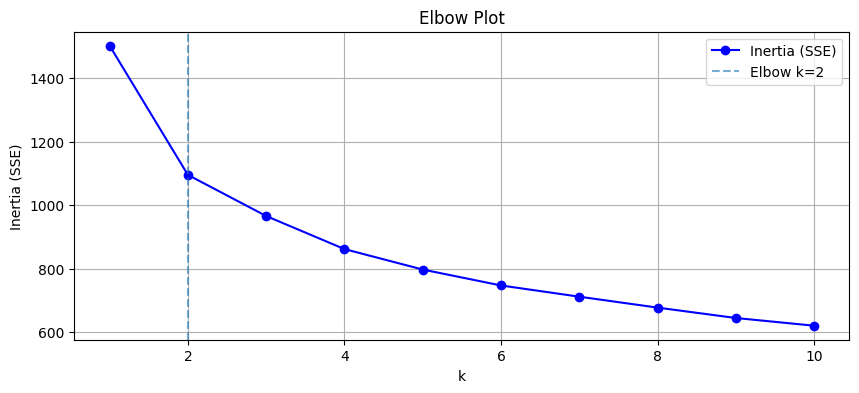

Suggested k (Elbow/SSE): 2


In [ ]:
print("Elbow method using SSE (TRAIN only)")

k_min, k_max = 1, 10
ks = list(range(k_min, k_max + 1))

inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train_pca)
    inertias.append(km.inertia_)

diff = np.diff(inertias)
ratio_drop = -(diff) / np.array(inertias[:-1])
k_elbow = ks[1 + int(np.argmax(ratio_drop))]

plt.figure(figsize=(10, 4))
plt.plot(ks, inertias, 'bo-', label='Inertia (SSE)')
plt.axvline(k_elbow, linestyle='--', alpha=0.6, label=f'Elbow k={k_elbow}')
plt.xlabel('k'); plt.ylabel('Inertia (SSE)'); plt.title('Elbow Plot')
plt.grid(True); plt.legend(); plt.show()

print(f"Suggested k (Elbow/SSE): {k_elbow}")

Silhouette method (TRAIN only)


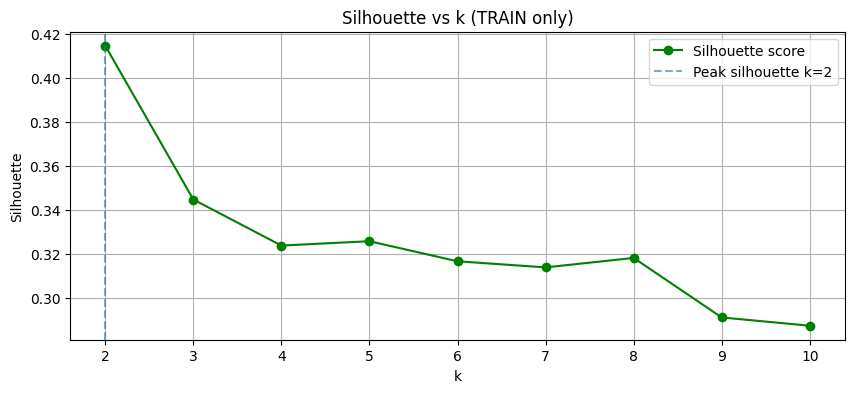

Suggested k (Silhouette peak): 2


In [ ]:
print("Silhouette method (TRAIN only)")

k_min, k_max = 2, 10
ks = list(range(k_min, k_max + 1))

silhouettes = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train_pca)
    s = silhouette_score(X_train_pca, km.labels_, metric="cosine")
    silhouettes.append(s)

k_sil = ks[int(np.argmax(silhouettes))]

plt.figure(figsize=(10, 4))
plt.plot(ks, silhouettes, 'go-', label='Silhouette score')
plt.axvline(k_sil, linestyle='--', alpha=0.6, label=f'Peak silhouette k={k_sil}')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.title('Silhouette vs k (TRAIN only)')
plt.grid(True); plt.legend(); plt.show()

print(f"Suggested k (Silhouette peak): {k_sil}")

In [ ]:
k = 2
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_train_pca)
train_clusters = kmeans.labels_
test_clusters  = kmeans.predict(X_test_pca)

print("Cluster counts (TRAIN):", np.bincount(train_clusters))
print(np.unique(train_clusters))

Cluster counts (TRAIN): [768 747]
[0 1]


t-SNE (TRAIN only)


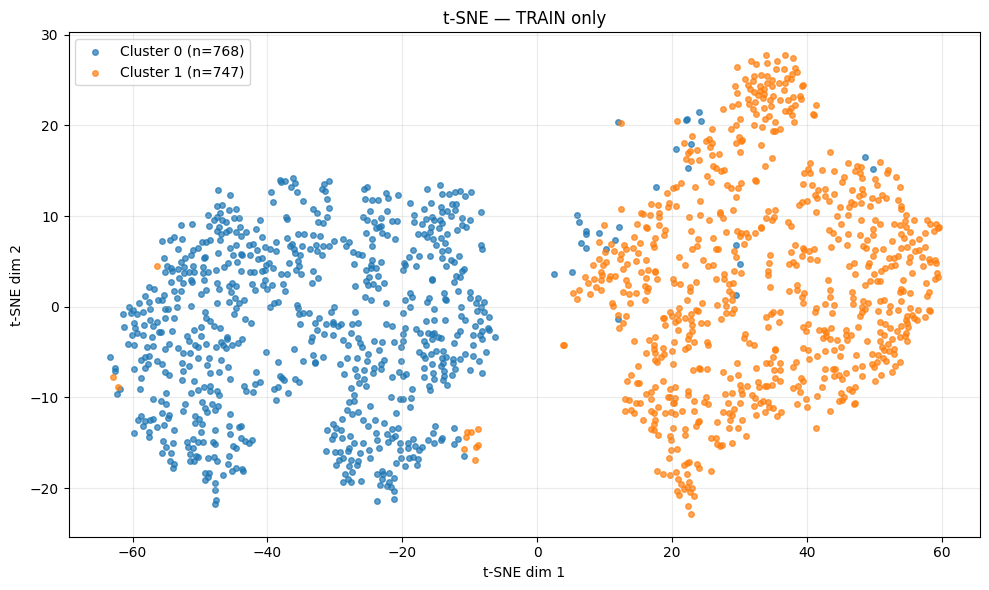

In [ ]:
print("t-SNE (TRAIN only)")

labels = np.asarray(train_clusters)
n = X_train_pca.shape[0]
perp = min(30, max(5, n // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perp,
    metric="cosine",
    init="pca",
    learning_rate="auto",
    max_iter=2000,
    random_state=42,
    verbose=0,
)
Xtr_tsne = tsne.fit_transform(X_train_pca)

plt.figure(figsize=(10, 6))
for cid in np.unique(labels):
    m = labels == cid
    plt.scatter(Xtr_tsne[m, 0], Xtr_tsne[m, 1], s=16, alpha=0.7,
                label=f"Cluster {cid} (n={m.sum()})")

plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.title("t-SNE — TRAIN only")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
print("t-SNE 3D (TRAIN only)")

labels = np.asarray(train_clusters)
n = X_train_pca.shape[0]
perp = min(30, max(5, n // 3))

tsne3d = TSNE(
    n_components=3,
    perplexity=perp,
    metric="cosine",
    init="pca",
    learning_rate="auto",
    max_iter=2000,
    random_state=42,
    verbose=0,
)
Xtr_tsne3 = tsne3d.fit_transform(X_train_pca)

# 3D scatter
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cid in np.unique(labels):
    m = (labels == cid)
    ax.scatter(Xtr_tsne3[m, 0], Xtr_tsne3[m, 1], Xtr_tsne3[m, 2],
               s=16, alpha=0.7, label=f"Cluster {cid} (n={m.sum()})")

ax.set_title("t-SNE — TRAIN only (3D)")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.set_zlabel("t-SNE dim 3")
ax.legend()
plt.tight_layout()
plt.show()

t-SNE 3D (TRAIN only)


In [ ]:
labels = np.asarray(train_clusters)
paths  = np.asarray(train_paths)[train_valid_idx]
n_samples = 5
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, n_samples, figsize=(3*n_samples, 6))
axes = np.atleast_2d(axes)

for cid in (0, 1):
    idxs = np.where(labels == cid)[0]
    pick = idxs if len(idxs) <= n_samples else rng.choice(idxs, n_samples, replace=False)

    for j in range(n_samples):
        ax = axes[cid, j]
        if j < len(pick):
            p = paths[pick[j]]
            img = cv2.imread(p)
            if img is None:
                ax.text(0.5, 0.5, "read error", ha="center", va="center")
            else:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                ax.set_title(f"Cluster {cid}")
        ax.axis("off")

plt.suptitle("Samples per cluster — TRAIN only")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sil_tr = silhouette_score(X_train_pca, train_clusters, metric="cosine")
db_tr  = davies_bouldin_score(X_train_pca, train_clusters)

sil_te = silhouette_score(X_test_pca,  test_clusters,  metric="cosine")
ch_te  = calinski_harabasz_score(X_test_pca,  test_clusters)
db_te  = davies_bouldin_score(X_test_pca,  test_clusters)

n_te = X_test_pca.shape[0]
R = 20
rng = np.random.RandomState(0)
ch_tr_vals = []
for _ in range(R):
    idx = rng.choice(X_train_pca.shape[0], size=n_te, replace=False)
    ch_tr_vals.append(calinski_harabasz_score(X_train_pca[idx], train_clusters[idx]))
ch_tr_mean = float(np.mean(ch_tr_vals))
ch_tr_std  = float(np.std(ch_tr_vals))

internal_metrics = pd.DataFrame({
    "Metric": ["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"],
    "Train":  [round(sil_tr,4), f"{ch_tr_mean + ch_tr_std:.6f}", round(db_tr,4)],
    "Test":   [round(sil_te,4), round(ch_te,2),                         round(db_te,4)]
})

internal_metrics


In [ ]:
def infer_label_from_path(p: str):
    if "nofire" in p: return 0
    if "/fire/" in p or "fire" in p: return 1
    return None

y_train_true = np.array([infer_label_from_path(train_paths[i]) for i in train_valid_idx])
y_test_true  = np.array([infer_label_from_path(test_paths[i])  for i in test_valid_idx])

cluster_to_label = {}
for cid in range(kmeans.n_clusters):
    mask = (train_clusters == cid)
    cluster_to_label[cid] = int(y_train_true[mask].mean() >= 0.5)

print("Cluster→Class mapping:", cluster_to_label)

In [ ]:
d_tr = kmeans.transform(X_train_pca)
d_te = kmeans.transform(X_test_pca)

fire_ids   = [c for c, lab in cluster_to_label.items() if lab == 1]
nofire_ids = [c for c, lab in cluster_to_label.items() if lab == 0]
assert len(fire_ids) > 0 and len(nofire_ids) > 0

d_fire_tr   = np.min(d_tr[:, fire_ids],   axis=1) if len(fire_ids)>1   else d_tr[:, fire_ids[0]]
d_nofire_tr = np.min(d_tr[:, nofire_ids], axis=1) if len(nofire_ids)>1 else d_tr[:, nofire_ids[0]]
d_fire_te   = np.min(d_te[:, fire_ids],   axis=1) if len(fire_ids)>1   else d_te[:, fire_ids[0]]
d_nofire_te = np.min(d_te[:, nofire_ids], axis=1) if len(nofire_ids)>1 else d_te[:, nofire_ids[0]]

score_tr = d_nofire_tr - d_fire_tr
score_te = d_nofire_te - d_fire_te

In [ ]:
y_test_pred = (score_te >= 0.0).astype(int)

print("Pre-tuning — Closest-centroid (t=0) — TEST")
print(classification_report(y_test_true, y_test_pred,target_names=["No Fire","Fire"], digits=4))

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Fire (0)", "Fire (1)"])

fig, ax = plt.subplots(figsize=(6,5), dpi=150)
disp.plot(cmap="Blues", values_format='d', ax=ax, colorbar=True)

plt.title("Confusion Matrix (Unsupervised)", weight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
prec, rec, thr = precision_recall_curve(y_train_true, score_tr, pos_label=1)
pr_auc = auc(rec, prec)

In [ ]:
beta = 1.5
P, R = prec[:-1], rec[:-1]
f_beta = (1 + beta**2) * P * R / (beta**2 * P + R + 1e-12)
best_idx = int(np.argmax(f_beta))
t_suggest = float(thr[best_idx])

print(f"Suggested threshold (TRAIN, F{beta:.0f}-max): {t_suggest}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), dpi=150)

axes[0].plot(thr, P, label="Precision")
axes[0].plot(thr, R, label="Recall")
axes[0].axvline(t_suggest, linestyle="--", label=f"THRESH = {t_suggest:.3f}")
axes[0].axvline(t_suggest, ls="--")
axes[0].set_title(f"Precision/Recall vs Threshold (β={beta})")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].legend(); axes[0].grid(True, ls="--", alpha=0.3)

axes[1].hist(score_tr[y_train_true==1], bins=40, alpha=0.6, label="Fire")
axes[1].hist(score_tr[y_train_true==0], bins=40, alpha=0.6, label="No Fire")
axes[1].axvline(t_suggest, ls="--")
axes[1].set_title("Score Distribution")
axes[1].set_xlabel("Score"); axes[1].set_ylabel("Count")
axes[1].legend(); axes[1].grid(True, ls="--", alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
y_test_pred_tuned = (score_te >= t_suggest).astype(int)
print("classification report")
print(classification_report(y_test_true, y_test_pred_tuned,target_names=["No Fire", "Fire"], digits=4))

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Fire (0)", "Fire (1)"])

fig, ax = plt.subplots(figsize=(6,5), dpi=150)
disp.plot(cmap="Blues", values_format='d', ax=ax, colorbar=True)

plt.title("Confusion Matrix (Unsupervised and tuned)", weight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
ari = adjusted_rand_score(y_test_true, test_clusters)
vms = v_measure_score(y_test_true, test_clusters)
nmi = normalized_mutual_info_score(y_test_true, test_clusters)

# Put results in a nice table
external_metrics = pd.DataFrame({
    "Metric": ["Adjusted Rand Index (ARI)", "V-Measure", "Normalized Mutual Info (NMI)"],
    "Score":  [ari, vms, nmi]
}).round(4)

external_metrics

Threshold=-0.101 | images=379 | DROP=197 | EXIT=182
- Location 1: score=-0.2400, risk=0.3054 -> EXIT
- Location 2: score=-0.5355, risk=0.1367 -> EXIT
- Location 3: score=-0.6920, risk=0.0473 -> EXIT
- Location 4: score=-0.2422, risk=0.3042 -> EXIT
- Location 5: score=-0.7749, risk=0.0000 -> EXIT
- Location 6: score=-0.6244, risk=0.0860 -> EXIT
- Location 7: score=0.5971, risk=0.7834 -> DROP
- Location 8: score=-0.3047, risk=0.2685 -> EXIT


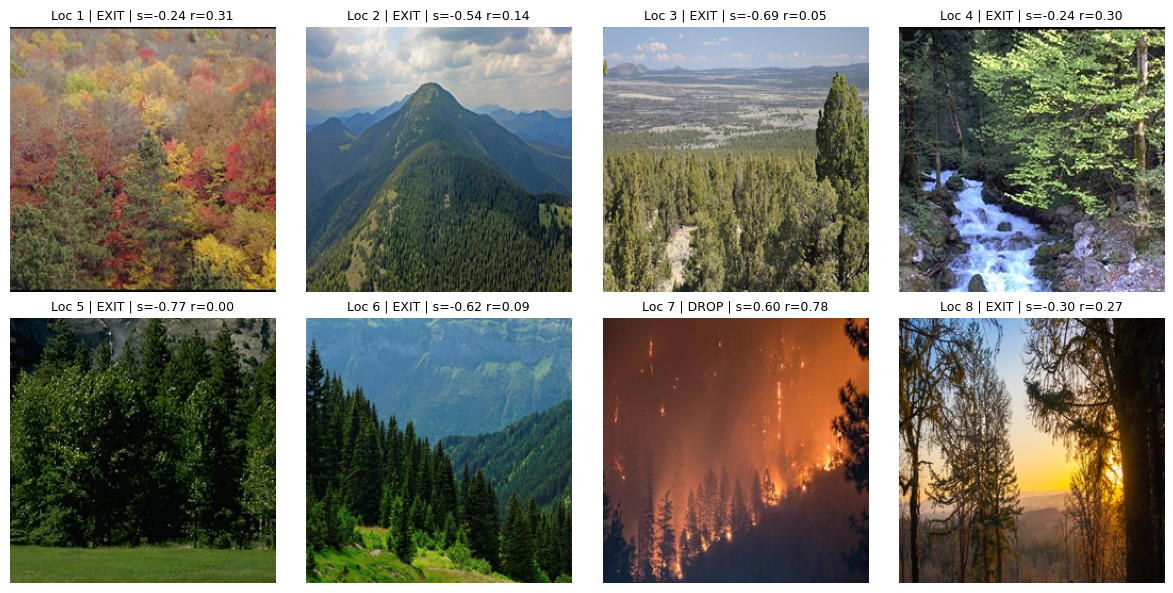

In [ ]:
def unsupervised_simulation(test_paths, score_te, shuffle=False):
    s   = np.asarray(score_te, dtype=float).ravel()
    thr = float(t_suggest)  # expects t_suggest to exist

    decisions = np.where(s >= thr, "DROP", "EXIT")

    # normalized risk (0..1) for display
    if s.size == 0:
        r = s
    else:
        lo, hi = s.min(), s.max()
        r = np.zeros_like(s) if hi == lo else (s - lo) / (hi - lo)

    # summary (show first 8)
    drops = int((decisions == "DROP").sum())
    print(f"Threshold={thr:.3f} | images={len(s)} | DROP={drops} | EXIT={len(s)-drops}")
    for i in range(min(8, len(s))):
        print(f"- Location {i+1}: score={s[i]:.4f}, risk={r[i]:.4f} -> {decisions[i]}")

    # pick up to 8 images (optionally shuffled)
    idx = np.arange(len(s))
    if shuffle:
        np.random.shuffle(idx)
    idx = idx[:min(8, len(idx))]

    # fixed grid: 2 rows x 4 cols, fixed figsize
    plt.figure(figsize=(12, 6))
    for j, k in enumerate(idx, start=1):
        ax = plt.subplot(2, 4, j)  # literal numbers
        ax.imshow(plt.imread(test_paths[k]))
        ax.axis("off")
        ax.set_title(f"Loc {k+1} | {decisions[k]} | s={s[k]:.2f} r={r[k]:.2f}", fontsize=9)
    plt.tight_layout()
    plt.show()

    return list(zip([f"Location {i+1}" for i in range(len(s))],
                    s.tolist(), r.tolist(), decisions.tolist()))

results_unsup = unsupervised_simulation(test_paths, score_te, shuffle=False)


In [ ]:
print("First 10 score_te values:")
for i, score in enumerate(score_te[:10]):
    print(f"Image {i+1}: score_te = {score:.4f}")

First 10 score_te values:
Image 1: score_te = -0.2400
Image 2: score_te = -0.5355
Image 3: score_te = -0.6920
Image 4: score_te = -0.2422
Image 5: score_te = -0.7749
Image 6: score_te = -0.6244
Image 7: score_te = 0.5971
Image 8: score_te = -0.3047
Image 9: score_te = -0.4909
Image 10: score_te = -0.5060
